## CARGANDO LOS DATOS

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/JuanCanchi19/challenger-3-alura-store-data-sciece/main/TelecomX_clean.csv"

df = pd.read_csv(url)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,TotalServicios
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667,4
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,3
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,2
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,5
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,3


## LIMPIEZA DE DATOS

In [2]:
df = df.drop(columns=["customerID"], errors="ignore")

In [3]:
df.head()
df.shape

(7043, 22)

## Encoding

Verificamos las columnas categoricas y demás:

In [4]:
# Ver tipos de datos
df.dtypes

,0
Churn,int64
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,object
OnlineSecurity,int64


In [5]:
# Identificar columnas categóricas
categoricas = df.select_dtypes(include=["object"]).columns

print("Columnas categóricas:")
print(categoricas)

Columnas categóricas:
Index(['gender', 'InternetService', 'Contract', 'PaymentMethod'], dtype='object')


In [6]:
# valores únicos
for col in categoricas:
    print(col, ":", df[col].unique())

gender : ['Female' 'Male']
InternetService : ['DSL' 'Fiber optic' 'No']
Contract : ['One year' 'Month-to-month' 'Two year']
PaymentMethod : ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


Aplicamos One-Hot Encoding

In [7]:
# variables categóricas
categoricas = ["gender", "InternetService", "Contract", "PaymentMethod"]

# one-hot encoding
df = pd.get_dummies(df, columns=categoricas, drop_first=True)

# verificar
df.head()
df.dtypes

,0
Churn,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64


convertir las columnas boleanos

In [8]:
# convertir columnas booleanas a 0 y 1
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

df.dtypes

,0
Churn,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64


## Verificación de la Proporción de Cancelación (Churn)

In [9]:
# Conteo de la variable objetivo
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [10]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


In [11]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.463013
1,26.536987


La variable objetivo presenta un desbalance moderado, donde aproximadamente 73% de los clientes permanecen y 27% cancelan el servicio. Este desbalance debe considerarse al entrenar los modelos predictivos, ya que podría afectar su capacidad para identificar correctamente a los clientes que cancelan.

## Normalización o Estandarización

In [12]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Cuentas_Diarias,TotalServicios,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,...,2.158723,3.362914,0.504756,0.439585,0.216669,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,...,1.003002,2.062031,0.500013,0.496372,0.412004,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.608333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.183333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,2.345000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.995000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.958333,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Separamos variables predictorias de dependiente

In [13]:
# variable objetivo
y = df["Churn"]

# variables predictoras
X = df.drop("Churn", axis=1)

print(X.shape)
print(y.shape)

(7043, 25)
(7043,)


Análisis de Correlación

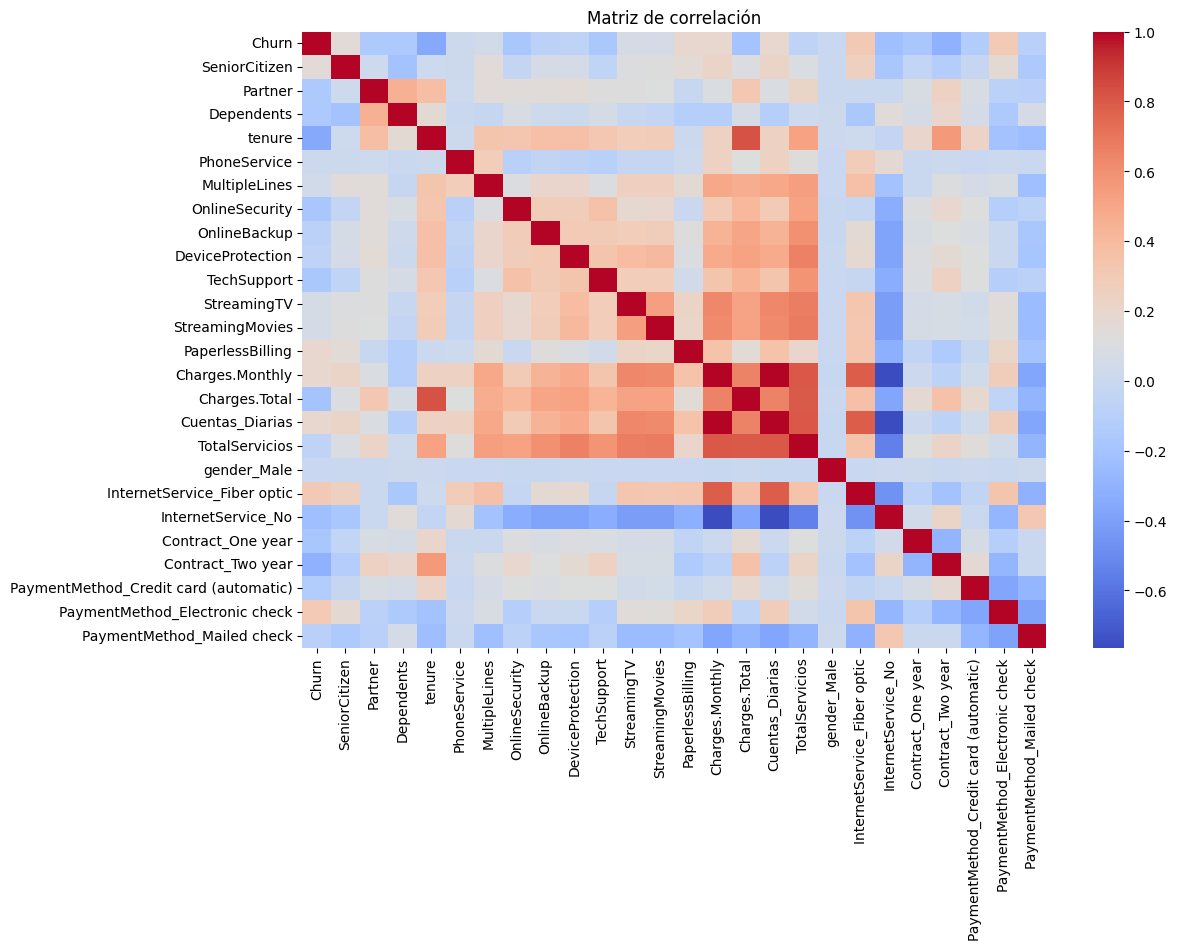

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de correlación")
plt.show()

Correlación con Churn

In [15]:
corr_churn = df.corr()["Churn"].sort_values(ascending=False)
corr_churn

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Charges.Monthly,0.193356
Cuentas_Diarias,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV,0.063228
StreamingMovies,0.061382
MultipleLines,0.040102


El análisis de correlación muestra que algunas variables tienen una relación moderada con la cancelación de clientes. Las variables con correlación positiva más alta con churn son InternetService_Fiber optic (0.31) y PaymentMethod_Electronic check (0.30), lo que sugiere que los clientes con fibra óptica o que pagan mediante cheque electrónico tienen mayor probabilidad de cancelar. También se observa cierta relación con Charges.Monthly y PaperlessBilling.

Por otro lado, las correlaciones negativas más relevantes corresponden a tenure (-0.35), Contract_Two year (-0.30) y Charges.Total (-0.20), lo que indica que los clientes con mayor tiempo en la empresa, contratos más largos o mayor gasto total tienden a cancelar menos el servicio.

## Análisis dirigido

1. Tiempo de contrato (tenure) vs cancelación

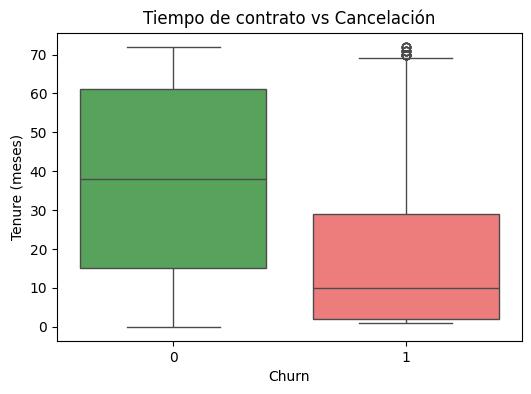

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette={0:"#4CAF50", 1:"#FF6B6B"},
    legend=False
)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Tenure (meses)")
plt.show()

2. Gasto total vs cancelación

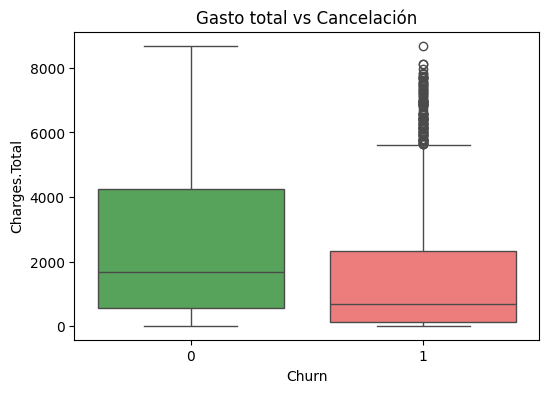

In [18]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="Charges.Total",
    hue="Churn",
    palette={0:"#4CAF50", 1:"#FF6B6B"},
    legend=False
)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Charges.Total")
plt.show()

Los gráficos muestran que los clientes que cancelan el servicio (Churn = 1) tienden a tener menor tiempo de permanencia (tenure) en comparación con los clientes que permanecen (Churn = 0). Esto sugiere que los clientes nuevos presentan mayor riesgo de cancelación.

En cuanto al gasto total (Charges.Total), los clientes que permanecen en la empresa presentan valores más altos, lo cual es consistente con el hecho de que llevan más tiempo contratando el servicio. Por el contrario, los clientes que cancelan suelen tener menor gasto acumulado, lo que nuevamente refleja una menor permanencia en la compañía.

 Modelado Predictivo

# Separación de datos

In [19]:
from sklearn.model_selection import train_test_split

# dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4930, 25)
Test: (2113, 25)


Creación de Modelos

1. Regresión Logística (con escalado)

In [24]:
X_train.isna().sum().sort_values(ascending=False)
df = df.dropna()
# separar nuevamente
X = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

modelo_log.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000, random_state=42))])

2. Random Forest (sin escalado)

In [26]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Para este análisis se implementaron dos modelos de clasificación con características diferentes. La Regresión Logística se utilizó como modelo base y se aplicó normalización mediante StandardScaler, ya que este tipo de algoritmo es sensible a la escala de las variables y requiere que los datos estén estandarizados para optimizar correctamente sus coeficientes.

Por otro lado, se utilizó Random Forest, un modelo basado en árboles de decisión que no depende de la escala de las variables, por lo que no requiere normalización. Este modelo permite capturar relaciones no lineales entre las variables y suele ofrecer un buen rendimiento en problemas de clasificación.

La comparación entre ambos modelos permite evaluar el comportamiento de un algoritmo lineal frente a un modelo basado en árboles para predecir la cancelación de clientes.

Los datos fueron normalizados únicamente para el modelo de Regresión Logística utilizando StandardScaler, ya que este tipo de algoritmo es sensible a la escala de las variables. En el caso de Random Forest, no se aplicó normalización porque los modelos basados en árboles no dependen de la magnitud de las variables para realizar sus divisiones.

## Evaluación de los Modelos

1. Predicciones

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predicciones
y_pred_log = modelo_log.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

2. Métricas

In [28]:
print("=== Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

=== Regresión Logística ===
Accuracy: 0.8037914691943128
Precision: 0.6443089430894309
Recall: 0.5701438848920863
F1-score: 0.6049618320610687

=== Random Forest ===
Accuracy: 0.7834123222748816
Precision: 0.6087912087912087
Recall: 0.4982014388489209
F1-score: 0.5479723046488625


3. Matriz de confusión

In [29]:
print("Matriz de confusión - Regresión Logística")
print(confusion_matrix(y_test, y_pred_log))

print("\nMatriz de confusión - Random Forest")
print(confusion_matrix(y_test, y_pred_rf))

Matriz de confusión - Regresión Logística
[[1379  175]
 [ 239  317]]

Matriz de confusión - Random Forest
[[1376  178]
 [ 279  277]]


4. Reporte completo

In [30]:
print("=== Reporte Regresión Logística ===")
print(classification_report(y_test, y_pred_log))

print("=== Reporte Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Reporte Regresión Logística ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1554
           1       0.64      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110

=== Reporte Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1554
           1       0.61      0.50      0.55       556

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.78      2110



Evaluación y comparación de los modelos

Los resultados muestran que la Regresión Logística tuvo un mejor desempeño general en comparación con Random Forest. Este modelo alcanzó una exactitud (accuracy) de 0.80, mientras que Random Forest obtuvo 0.78. Además, la Regresión Logística presentó mejores valores de precisión (0.64), recall (0.57) y F1-score (0.60) para la clase de cancelación.

En la matriz de confusión, la Regresión Logística logró identificar correctamente más casos de cancelación (317) que Random Forest (277). Esto indica que el modelo es más eficaz para detectar clientes que podrían abandonar el servicio.

En cuanto al overfitting o underfitting, no se observan señales claras de overfitting, ya que el rendimiento es consistente y no excesivamente alto. Sin embargo, ambos modelos presentan recall moderado para la clase churn, lo que sugiere que todavía existen clientes que cancelan y que el modelo no logra identificar correctamente. Esto puede deberse al desbalance de clases en el dataset, donde los clientes que permanecen son significativamente más numerosos.

En conclusión, la Regresión Logística mostró el mejor desempeño para este problema, ofreciendo un equilibrio más adecuado entre precisión y capacidad para detectar cancelaciones. Para mejorar los resultados en el futuro, se podrían explorar técnicas como balanceo de clases (SMOTE), ajuste de hiperparámetros o modelos más complejos.

## Análisis de la Importancia de las Variables

1. Importancia de variables — Regresión Logística

In [31]:
import pandas as pd

coeficientes = pd.Series(
    modelo_log.named_steps["logreg"].coef_[0],
    index=X.columns
)

coeficientes.sort_values(ascending=False)

,0
Charges.Total,0.938944
InternetService_Fiber optic,0.638816
StreamingTV,0.191861
PaymentMethod_Electronic check,0.176350
StreamingMovies,0.174084
MultipleLines,0.173946
PaperlessBilling,0.171127
SeniorCitizen,0.093345
TotalServicios,0.051329
DeviceProtection,0.035199


In [32]:
coeficientes.sort_values(key=abs, ascending=False).head(10)

,0
tenure,-1.626243
Charges.Total,0.938944
Contract_Two year,-0.665518
InternetService_Fiber optic,0.638816
InternetService_No,-0.549203
Cuentas_Diarias,-0.355866
Charges.Monthly,-0.355866
Contract_One year,-0.301689
StreamingTV,0.191861
PaymentMethod_Electronic check,0.176350


2. Importancia de variables — Random Forest

In [33]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
)

importancias.sort_values(ascending=False).head(10)

,0
Charges.Total,0.163992
tenure,0.162080
Cuentas_Diarias,0.128178
Charges.Monthly,0.128032
InternetService_Fiber optic,0.043767
PaymentMethod_Electronic check,0.035267
TotalServicios,0.032935
Contract_Two year,0.031245
gender_Male,0.023943
PaperlessBilling,0.023319


A partir de los coeficientes de la Regresión Logística y de la importancia de variables obtenida con Random Forest, se identificaron los factores que más influyen en la cancelación de clientes.

En la Regresión Logística, las variables con mayor impacto en la predicción fueron tenure, Charges.Total, Contract_Two year e InternetService_Fiber optic. La variable tenure presenta el coeficiente negativo más fuerte, lo que indica que los clientes con mayor tiempo en la empresa tienen una menor probabilidad de cancelar el servicio. De manera similar, los contratos de dos años también reducen significativamente la probabilidad de churn, lo que sugiere que los compromisos a largo plazo favorecen la retención de clientes.

Por otro lado, variables como InternetService_Fiber optic y PaymentMethod_Electronic check presentan coeficientes positivos, lo que indica que los clientes con estas características tienden a mostrar una mayor probabilidad de cancelación.

En el caso de Random Forest, las variables más importantes para la predicción fueron Charges.Total, tenure, Cuentas_Diarias y Charges.Monthly, lo que refuerza la idea de que el nivel de gasto y el tiempo de permanencia son factores clave en el comportamiento de cancelación.

En conjunto, ambos modelos coinciden en que el tiempo de permanencia del cliente, el tipo de contrato y el nivel de gasto en los servicios son algunos de los factores más determinantes para explicar la cancelación en Telecom X.

## CONCLUSIÓN

Informe Final – Predicción de Cancelación de Clientes (Churn)

1. Objetivo

El objetivo de este análisis fue desarrollar modelos predictivos capaces de identificar clientes con mayor probabilidad de cancelar sus servicios en Telecom X. Para ello, se utilizaron datos previamente tratados y estandarizados, buscando no solo construir modelos de clasificación, sino también comprender qué factores influyen con mayor fuerza en la cancelación.

2. Preparación de los datos

Se trabajó con el dataset limpio proveniente de la primera parte del desafío. En esta etapa se realizaron las siguientes acciones:

- Eliminación de columnas sin valor predictivo, como el identificador del cliente.

- Conversión de variables categóricas a formato numérico mediante One-Hot Encoding.

- Transformación de variables binarias a valores 0 y 1.

- Verificación de desbalance de clases en la variable objetivo Churn.

- Separación de variables predictoras (X) y variable objetivo (y).

- División del conjunto de datos en entrenamiento y prueba.

- Normalización de los datos únicamente para el modelo de Regresión Logística, ya que este algoritmo es sensible a la escala de las variables.

3. Modelos utilizados

Se entrenaron dos modelos de clasificación:

- Regresión Logística, utilizando normalización con StandardScaler.

- Random Forest, sin necesidad de normalización.

La elección de estos modelos permitió comparar el desempeño de un algoritmo lineal e interpretable frente a un modelo basado en árboles, más flexible para capturar relaciones no lineales.

4. Evaluación de los modelos

Regresión Logística
- Accuracy: 0.80
- Precision: 0.64
- Recall: 0.57
- F1-score: 0.60

Random Forest
- Accuracy: 0.78
- Precision: 0.61
- Recall: 0.50
- F1-score: 0.55

Análisis comparativo

La Regresión Logística presentó un mejor desempeño general en todas las métricas evaluadas, especialmente en la capacidad para identificar clientes que cancelan el servicio. También logró un mejor equilibrio entre precisión y recall, por lo que se considera el modelo más adecuado entre los dos evaluados.

No se observan señales evidentes de overfitting extremo, aunque ambos modelos muestran margen de mejora en la predicción de la clase minoritaria (clientes que cancelan). Esto puede estar relacionado con el desbalance moderado de la variable objetivo

5. Factores que más influyen en la cancelación

El análisis de coeficientes en la Regresión Logística y la importancia de variables en Random Forest permitió identificar los principales factores asociados al churn.

Variables más relevantes encontradas

- tenure
Fue una de las variables más influyentes en ambos modelos. Los clientes con menor tiempo en la empresa presentan mayor probabilidad de cancelar.

- Charges.Total
También tuvo alta relevancia. Los clientes con menor gasto acumulado tienden a abandonar más, lo cual está relacionado con una menor permanencia.

- Contract_Two year / Contract_One year
Los contratos de largo plazo reducen significativamente la probabilidad de cancelación. Los clientes con contratos mensuales son más propensos al churn.

- InternetService_Fiber optic
Presenta una asociación positiva con la cancelación, lo que sugiere que este tipo de servicio puede estar relacionado con mayor insatisfacción, precio o expectativa del cliente.

- PaymentMethod_Electronic check
También se relaciona positivamente con churn, indicando que ciertos métodos de pago pueden asociarse a un mayor riesgo de cancelación.

- Charges.Monthly / Cuentas_Diarias
Los cargos mensuales y diarios muestran relación con la cancelación, sugiriendo que clientes con determinados niveles de gasto presentan mayor riesgo de abandono.

6. Conclusiones estratégicas

A partir del análisis realizado, se concluye que los principales factores que afectan la cancelación de clientes en Telecom X son:

- Poca antigüedad del cliente en la empresa

- Contratos mensuales en lugar de contratos de largo plazo

- Menor gasto acumulado

- Clientes con servicio de fibra óptica

- Uso de Electronic check como método de pago

Estos resultados indican que el churn no depende de un único factor, sino de una combinación de permanencia, tipo de contrato, nivel de gasto y ciertas características del servicio contratado.

7. Recomendaciones de retención

Con base en los hallazgos obtenidos, se proponen las siguientes estrategias:

- Fortalecer la retención en los primeros meses del cliente, ya que este grupo presenta mayor probabilidad de cancelación.

- Promover contratos de largo plazo mediante descuentos, beneficios o planes especiales.

- Revisar la experiencia de clientes con Fiber optic, ya que este segmento muestra mayor riesgo de abandono.

- Analizar el método de pago Electronic check, para identificar posibles fricciones en el proceso de cobro o perfil de riesgo.

- Diseñar estrategias de fidelización para clientes con bajo gasto acumulado, quienes podrían abandonar antes de consolidar una relación con la empresa.

8. Cierre

En general, el proyecto permitió construir un pipeline inicial de Machine Learning para predecir la cancelación de clientes y, al mismo tiempo, identificar factores estratégicos que pueden apoyar decisiones de negocio. Entre los modelos evaluados, la Regresión Logística mostró el mejor rendimiento y ofreció además una interpretación clara de las variables más relevantes para el churn.